In [ ]:
!pip install -q transformer-lens

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from transformer_lens import HookedTransformer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HookedTransformer.from_pretrained(
    "gpt2",
    device=device
)

model.eval()


In [4]:
print(device)

cuda


In [5]:

df = pd.read_csv("/kaggle/input/datasets/hosseinrezaeian/synthetic/ioi_synthetic_dataset.csv")

print("Device:", device)
print("Dataset size:", len(df))

Device: cuda
Dataset size: 1000


In [6]:
row = df.iloc[0]

print(row["clean_prompt"])
print()

tokens = model.to_str_tokens(row["clean_prompt"])

for i, token in enumerate(tokens):
    print(i, repr(token))

When Carol and Frank arrived at school, Frank showed the picture to

0 '<|endoftext|>'
1 'When'
2 ' Carol'
3 ' and'
4 ' Frank'
5 ' arrived'
6 ' at'
7 ' school'
8 ','
9 ' Frank'
10 ' showed'
11 ' the'
12 ' picture'
13 ' to'


In [7]:
def find_name_positions(prompt, names):
    tokens = model.to_str_tokens(prompt)
    
    positions = {}
    
    for i, token in enumerate(tokens):
        cleaned = token.strip()
        
        if cleaned in names:
            positions[cleaned] = i
    
    return positions

In [8]:
positions = find_name_positions(
    row["clean_prompt"],
    [row["A"], row["B"]]
)

print(positions)

{'Carol': 2, 'Frank': 9}


In [9]:
def logit_diff_from_logits(logits, correct, incorrect):
    correct_id = model.to_single_token(" " + correct)
    incorrect_id = model.to_single_token(" " + incorrect)

    correct_logit = logits[0, -1, correct_id]
    incorrect_logit = logits[0, -1, incorrect_id]

    return correct_logit - incorrect_logit

In [10]:
def get_cache(prompt):
    tokens = model.to_tokens(prompt)
    
    with torch.no_grad():
        logits, cache = model.run_with_cache(tokens)
    
    return tokens, logits, cache

In [11]:
row = df.iloc[0]

clean_tokens, clean_logits, clean_cache = get_cache(
    row["clean_prompt"]
)

corrupt_tokens, corrupt_logits, corrupt_cache = get_cache(
    row["corrupted_prompt"]
)

print(clean_tokens.shape)
print(corrupt_tokens.shape)

torch.Size([1, 14])
torch.Size([1, 14])


In [12]:
print("Clean length:",clean_tokens.shape[1])

print("Corrupted length:",corrupt_tokens.shape[1])

Clean length: 14
Corrupted length: 14


In [13]:
row = df.iloc[0]

clean_ld = logit_diff_from_logits(
    clean_logits,
    row["clean_correct"],
    row["clean_incorrect"]
)

corrupt_ld = logit_diff_from_logits(
    corrupt_logits,
    row["clean_correct"],
    row["clean_incorrect"]
)

print("Clean logit difference:", clean_ld.item())
print("Corrupted logit difference:", corrupt_ld.item())

Clean logit difference: 3.5837831497192383
Corrupted logit difference: -1.8502378463745117


In [14]:
def normalized_patch_score(
    patched_ld,
    clean_ld,
    corrupt_ld
):
    denominator = clean_ld - corrupt_ld
    
    if abs(denominator.item()) < 1e-6:
        return torch.tensor(0.0, device=patched_ld.device)
    
    return (
        (patched_ld - corrupt_ld)
        / denominator
    )

In [15]:
# for key in clean_cache.keys():
#     print(key)

In [16]:
layer = 5

hook_name = f"blocks.{layer}.hook_resid_pre"

print(hook_name)

blocks.5.hook_resid_pre


In [17]:
def patch_residual_hook(clean_cache,hook_name,position):
    
    def hook_fn(activation,hook):
        activation[:, position, :] = clean_cache[hook_name][:, position, :]
        return activation
    
    return hook_fn

In [18]:
row = df.iloc[0]

clean_tokens, clean_logits, clean_cache = get_cache(
    row["clean_prompt"]
)

corrupt_tokens = model.to_tokens(
    row["corrupted_prompt"]
)

clean_ld = logit_diff_from_logits(
    clean_logits,
    row["clean_correct"],
    row["clean_incorrect"]
)

corrupt_logits = model(corrupt_tokens)

corrupt_ld = logit_diff_from_logits(
    corrupt_logits,
    row["clean_correct"],
    row["clean_incorrect"]
)

position = clean_tokens.shape[1] - 1

hook_name = "blocks.5.hook_resid_pre"

hook = patch_residual_hook(
    clean_cache,
    hook_name,
    position
)

with torch.no_grad():
    patched_logits = model.run_with_hooks(
        corrupt_tokens,
        fwd_hooks=[(hook_name, hook)]
    )

patched_ld = logit_diff_from_logits(
    patched_logits,
    row["clean_correct"],
    row["clean_incorrect"]
)

score = normalized_patch_score(
    patched_ld,
    clean_ld,
    corrupt_ld
)

print("Clean:", clean_ld.item())
print("Corrupt:", corrupt_ld.item())
print("Patched:", patched_ld.item())
print("Normalized patch score:", score.item())

Clean: 3.5837831497192383
Corrupt: -1.8502378463745117
Patched: -1.865647315979004
Normalized patch score: -0.0028357398696243763


In [19]:
def patch_layer(
    row,
    layer,
    position
):
    
    clean_tokens, clean_logits, clean_cache = get_cache(
        row["clean_prompt"]
    )
    
    corrupt_tokens = model.to_tokens(
        row["corrupted_prompt"]
    )
    
    with torch.no_grad():
        corrupt_logits = model(corrupt_tokens)
    
    clean_ld = logit_diff_from_logits(
        clean_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    corrupt_ld = logit_diff_from_logits(
        corrupt_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    hook_name = f"blocks.{layer}.hook_resid_pre"
    
    hook = patch_residual_hook(
        clean_cache,
        hook_name,
        position
    )
    
    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            corrupt_tokens,
            fwd_hooks=[(hook_name, hook)]
        )
    
    patched_ld = logit_diff_from_logits(
        patched_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    score = normalized_patch_score(
        patched_ld,
        clean_ld,
        corrupt_ld
    )
    
    return score.item()

In [20]:
row = df.iloc[0]

seq_len = len(
    model.to_str_tokens(
        row["corrupted_prompt"]
    )
)

position = seq_len - 1

layer_scores = []

for layer in tqdm(range(model.cfg.n_layers)):
    
    score = patch_layer(
        row,
        layer,
        position
    )
    
    layer_scores.append(score)

layer_scores

  0%|          | 0/12 [00:00<?, ?it/s]

[0.0,
 -0.00046244426630437374,
 0.001005092286504805,
 -0.001282558892853558,
 -0.0012041100999340415,
 -0.0028357398696243763,
 -0.001167254988104105,
 -0.010388586670160294,
 0.08171363919973373,
 0.2781853973865509,
 0.6243280172348022,
 0.8872332572937012]

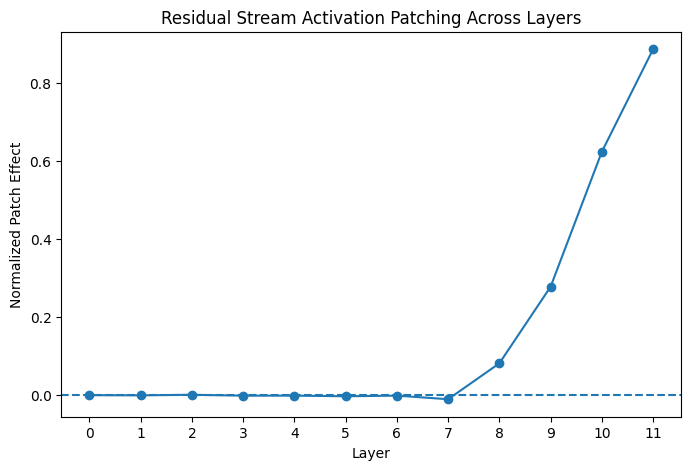

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(model.cfg.n_layers),
    layer_scores,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Layer")
plt.ylabel("Normalized Patch Effect")
plt.title(
    "Residual Stream Activation Patching Across Layers"
)

plt.xticks(range(model.cfg.n_layers))

plt.show()

In [22]:
def patch_layer_position(row,layer,position):
    
    clean_tokens, clean_logits, clean_cache = get_cache(
        row["clean_prompt"]
    )
    
    corrupt_tokens = model.to_tokens(
        row["corrupted_prompt"]
    )
    
    with torch.no_grad():
        corrupt_logits = model(corrupt_tokens)
    
    clean_ld = logit_diff_from_logits(
        clean_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    corrupt_ld = logit_diff_from_logits(
        corrupt_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    hook_name = f"blocks.{layer}.hook_resid_pre"
    
    def hook_fn(activation, hook):
        activation[:, position, :] = clean_cache[
            hook_name
        ][:, position, :]
        
        return activation
    
    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            corrupt_tokens,
            fwd_hooks=[(hook_name, hook_fn)]
        )
    
    patched_ld = logit_diff_from_logits(
        patched_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    return normalized_patch_score(
        patched_ld,
        clean_ld,
        corrupt_ld
    ).item()

In [23]:
N_SAMPLES = 1000

results = []

for sample_idx in tqdm(range(N_SAMPLES), desc="Samples"):

    row = df.iloc[sample_idx]

    position = (
        model.to_tokens(
            row["clean_prompt"]
        ).shape[1] - 1
    )

    for layer in range(model.cfg.n_layers):

        score = patch_layer(
            row=row,
            layer=layer,
            position=position
        )

        results.append({
            "sample": sample_idx,
            "layer": layer,
            "patch_score": score
        })

Samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [24]:
results_df = pd.DataFrame(results)

In [25]:
results_df.head()

,sample,layer,patch_score
0,0,0,0.000000
1,0,1,-0.000462
2,0,2,0.001005
3,0,3,-0.001283
4,0,4,-0.001204


In [26]:
layer_summary = (
    results_df
    .groupby("layer")["patch_score"]
    .agg(
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

layer_summary

,layer,mean,std,median,min,max
0,0,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,-0.000253,0.001734,-0.000231,-0.009704,0.023759
2,2,0.000247,0.005174,-0.000140,-0.016902,0.126694
3,3,0.000202,0.007492,-0.000098,-0.039600,0.171779
4,4,-0.000170,0.007921,-0.000384,-0.053810,0.119260
5,5,-0.000502,0.009535,-0.000573,-0.058057,0.059159
6,6,-0.000314,0.012196,-0.000699,-0.124908,0.070216
7,7,0.003149,0.018468,0.001922,-0.132017,0.082738
8,8,0.108934,0.064680,0.106232,-0.111367,0.480780
9,9,0.265005,0.123079,0.267714,-0.086526,1.009772


# Attention head patching

In [27]:
def patch_head_hook(clean_cache,hook_name,position,head):
    
    def hook_fn(activation,hook):
        
        activation[:, position, head, :] = (
            clean_cache[hook_name][
                :, position, head, :
            ]
        )
        
        return activation
    
    return hook_fn

In [28]:
def patch_attention_head(
    row,
    layer,
    head,
    position
):
    
    clean_tokens, clean_logits, clean_cache = get_cache(
        row["clean_prompt"]
    )
    
    corrupt_tokens = model.to_tokens(
        row["corrupted_prompt"]
    )
    
    with torch.no_grad():
        corrupt_logits = model(corrupt_tokens)
    
    clean_ld = logit_diff_from_logits(
        clean_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    corrupt_ld = logit_diff_from_logits(
        corrupt_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    hook_name = f"blocks.{layer}.attn.hook_z"
    
    hook = patch_head_hook(
        clean_cache,
        hook_name,
        position,
        head
    )
    
    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            corrupt_tokens,
            fwd_hooks=[
                (hook_name, hook)
            ]
        )
    
    patched_ld = logit_diff_from_logits(
        patched_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    score = normalized_patch_score(
        patched_ld,
        clean_ld,
        corrupt_ld
    )
    
    return score.item()

In [29]:
row = df.iloc[0]

position = (
    model.to_tokens(
        row["clean_prompt"]
    ).shape[1] - 1
)

head_scores = []

for head in range(model.cfg.n_heads):
    
    score = patch_attention_head(
        row=row,
        layer=11,
        head=head,
        position=position
    )
    
    head_scores.append(score)

head_scores

[0.008447549305856228,
 0.01124625839293003,
 -0.20065359771251678,
 0.009434038773179054,
 -0.0008859273511916399,
 0.0005193064571358263,
 -0.10723599791526794,
 0.0018741716630756855,
 0.01038279477506876,
 -0.004467545077204704,
 -0.3620617389678955,
 0.0319407694041729]

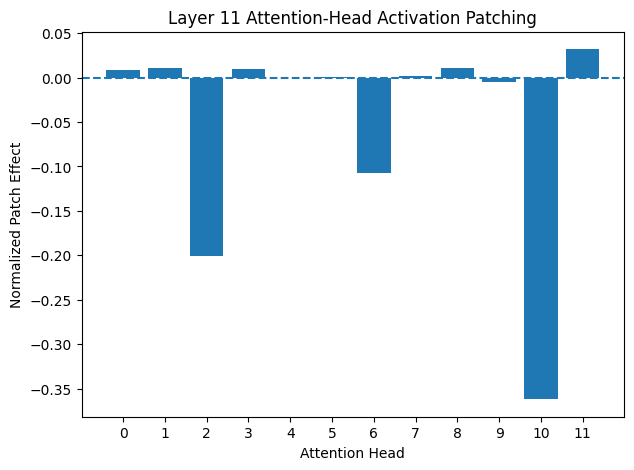

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    range(model.cfg.n_heads),
    head_scores
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Attention Head")
plt.ylabel("Normalized Patch Effect")

plt.title(
    "Layer 11 Attention-Head Activation Patching"
)

plt.xticks(
    range(model.cfg.n_heads)
)

plt.show()

In [31]:
N_SAMPLES = 1000

head_results = []

for sample_idx in tqdm(
    range(N_SAMPLES),
    desc="Samples"
):
    
    row = df.iloc[sample_idx]
    
    position = (
        model.to_tokens(
            row["clean_prompt"]
        ).shape[1] - 1
    )
    
    for layer in [10, 11]:
        
        for head in range(model.cfg.n_heads):
            
            score = patch_attention_head(
                row=row,
                layer=layer,
                head=head,
                position=position
            )
            
            head_results.append({
                "sample": sample_idx,
                "layer": layer,
                "head": head,
                "patch_score": score
            })

Samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [32]:
head_results_df = pd.DataFrame(
    head_results
)

head_summary = (
    head_results_df
    .groupby(["layer", "head"])["patch_score"]
    .agg(
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

head_summary

,layer,head,mean,std,median,min,max
0,10,0,0.101450,0.064668,0.088318,-0.153481,0.569496
1,10,1,0.056123,0.066283,0.037453,-0.080857,0.684671
2,10,2,-0.039883,0.055165,-0.024782,-0.533461,0.028164
3,10,3,0.002296,0.010042,0.001369,-0.065380,0.054486
4,10,4,-0.001572,0.009884,-0.000392,-0.251832,0.020972
5,10,5,0.000296,0.001904,0.000377,-0.010632,0.009768
6,10,6,0.067685,0.063587,0.042911,-0.027770,0.394550
7,10,7,-0.432162,0.318923,-0.462770,-2.779905,0.505856
8,10,8,-0.000180,0.001225,-0.000138,-0.006115,0.006255
9,10,9,0.013136,0.014198,0.009110,-0.009402,0.096855


In [38]:
positive_fraction = (
    head_results_df
    .groupby(["layer", "head"])["patch_score"]
    .apply(lambda x: (x > 0).mean())
    .reset_index(name="positive_fraction")
)

In [39]:
negative_fraction = (
    head_results_df
    .groupby(["layer", "head"])["patch_score"]
    .apply(lambda x: (x < 0).mean())
    .reset_index(name="negative_fraction")
)

In [40]:
head_summary = head_summary.merge(
    positive_fraction,
    on=["layer", "head"]
)

head_summary = head_summary.merge(
    negative_fraction,
    on=["layer", "head"]
)

In [41]:
head_summary.head()

,layer,head,mean,std,median,min,max,positive_fraction,negative_fraction
0,10,0,0.101450,0.064668,0.088318,-0.153481,0.569496,0.985,0.015
1,10,1,0.056123,0.066283,0.037453,-0.080857,0.684671,0.920,0.080
2,10,2,-0.039883,0.055165,-0.024782,-0.533461,0.028164,0.132,0.868
3,10,3,0.002296,0.010042,0.001369,-0.065380,0.054486,0.605,0.395
4,10,4,-0.001572,0.009884,-0.000392,-0.251832,0.020972,0.441,0.559


In [42]:
head_summary.sort_values('positive_fraction',ascending=False).head(10)

,layer,head,mean,std,median,min,max,positive_fraction,negative_fraction
23,11,11,0.031503,0.021596,0.026029,0.001646,0.372333,1.000,0.000
6,10,6,0.067685,0.063587,0.042911,-0.027770,0.394550,0.995,0.005
0,10,0,0.101450,0.064668,0.088318,-0.153481,0.569496,0.985,0.015
15,11,3,0.031561,0.039814,0.021655,-0.072099,0.751500,0.956,0.044
9,10,9,0.013136,0.014198,0.009110,-0.009402,0.096855,0.943,0.057
12,11,0,0.008699,0.009774,0.006825,-0.003581,0.168630,0.941,0.059
1,10,1,0.056123,0.066283,0.037453,-0.080857,0.684671,0.920,0.080
10,10,10,0.049875,0.041730,0.051136,-0.233312,0.193694,0.909,0.091
13,11,1,0.035598,0.051261,0.021948,-0.152012,0.514124,0.862,0.138
11,10,11,0.003744,0.004656,0.003111,-0.023946,0.051628,0.853,0.147


In [43]:
head_summary.sort_values("mean",ascending=False).head(10)

,layer,head,mean,std,median,min,max,positive_fraction,negative_fraction
0,10,0,0.101450,0.064668,0.088318,-0.153481,0.569496,0.985,0.015
6,10,6,0.067685,0.063587,0.042911,-0.027770,0.394550,0.995,0.005
1,10,1,0.056123,0.066283,0.037453,-0.080857,0.684671,0.920,0.080
10,10,10,0.049875,0.041730,0.051136,-0.233312,0.193694,0.909,0.091
13,11,1,0.035598,0.051261,0.021948,-0.152012,0.514124,0.862,0.138
15,11,3,0.031561,0.039814,0.021655,-0.072099,0.751500,0.956,0.044
23,11,11,0.031503,0.021596,0.026029,0.001646,0.372333,1.000,0.000
9,10,9,0.013136,0.014198,0.009110,-0.009402,0.096855,0.943,0.057
21,11,9,0.012733,0.027566,0.007294,-0.146379,0.220337,0.799,0.201
12,11,0,0.008699,0.009774,0.006825,-0.003581,0.168630,0.941,0.059


In [44]:
head_summary.sort_values('positive_fraction',ascending=True).head(10)

,layer,head,mean,std,median,min,max,positive_fraction,negative_fraction
22,11,10,-0.322021,0.195234,-0.299982,-3.884667,0.072957,0.008,0.992
14,11,2,-0.118491,0.151637,-0.084508,-3.302301,0.056463,0.029,0.971
7,10,7,-0.432162,0.318923,-0.462770,-2.779905,0.505856,0.118,0.882
2,10,2,-0.039883,0.055165,-0.024782,-0.533461,0.028164,0.132,0.868
18,11,6,-0.051175,0.076845,-0.028196,-0.700059,0.078038,0.178,0.822
17,11,5,-0.002663,0.005669,-0.002026,-0.098836,0.012736,0.266,0.734
16,11,4,-0.000838,0.003452,-0.000577,-0.020157,0.016012,0.394,0.606
8,10,8,-0.000180,0.001225,-0.000138,-0.006115,0.006255,0.408,0.592
4,10,4,-0.001572,0.009884,-0.000392,-0.251832,0.020972,0.441,0.559
5,10,5,0.000296,0.001904,0.000377,-0.010632,0.009768,0.602,0.398


In [45]:
top_positive_heads = (
    head_summary[
        head_summary["mean"] > 0
    ]
    .sort_values(
        ["positive_fraction", "mean"],
        ascending=[False, False]
    )
    .head(10)
)

top_positive_heads

,layer,head,mean,std,median,min,max,positive_fraction,negative_fraction
23,11,11,0.031503,0.021596,0.026029,0.001646,0.372333,1.000,0.000
6,10,6,0.067685,0.063587,0.042911,-0.027770,0.394550,0.995,0.005
0,10,0,0.101450,0.064668,0.088318,-0.153481,0.569496,0.985,0.015
15,11,3,0.031561,0.039814,0.021655,-0.072099,0.751500,0.956,0.044
9,10,9,0.013136,0.014198,0.009110,-0.009402,0.096855,0.943,0.057
12,11,0,0.008699,0.009774,0.006825,-0.003581,0.168630,0.941,0.059
1,10,1,0.056123,0.066283,0.037453,-0.080857,0.684671,0.920,0.080
10,10,10,0.049875,0.041730,0.051136,-0.233312,0.193694,0.909,0.091
13,11,1,0.035598,0.051261,0.021948,-0.152012,0.514124,0.862,0.138
11,10,11,0.003744,0.004656,0.003111,-0.023946,0.051628,0.853,0.147


# Causal intervention

In [46]:
def ablate_head_hook(activation, hook,head):
    activation[:, :, head, :] = 0
    return activation

In [47]:
def ablate_attention_head(row,layer,head):
    
    clean_tokens, clean_logits, clean_cache = get_cache(
        row["clean_prompt"]
    )
    
    corrupt_tokens = model.to_tokens(
        row["corrupted_prompt"]
    )
    
    with torch.no_grad():
        corrupt_logits = model(corrupt_tokens)
    
    clean_ld = logit_diff_from_logits(
        clean_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    corrupt_ld = logit_diff_from_logits(
        corrupt_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    hook_name = f"blocks.{layer}.attn.hook_z"
    
    def hook_fn(activation,hook):
        activation[:, :, head, :] = 0
        return activation
    
    with torch.no_grad():
        ablated_logits = model.run_with_hooks(
            corrupt_tokens,
            fwd_hooks=[
                (hook_name, hook_fn)
            ]
        )
    
    ablated_ld = logit_diff_from_logits(
        ablated_logits,
        row["clean_correct"],
        row["clean_incorrect"]
    )
    
    return (
        clean_ld.item(),
        corrupt_ld.item(),
        ablated_ld.item()
    )

In [48]:
row = df.iloc[5]

clean_ld, corrupt_ld, ablated_ld = (
    ablate_attention_head(
        row=row,
        layer=10,
        head=0
    )
)

print("Clean:", clean_ld)
print("Corrupt:", corrupt_ld)
print("Ablated:", ablated_ld)

Clean: 3.4572267532348633
Corrupt: -3.6377344131469727
Ablated: -2.998692512512207


In [49]:
ablation_results = []
Num_samples=1000
for _, candidate in top_positive_heads.iterrows():
    
    layer = int(candidate["layer"])
    head = int(candidate["head"])
    
    print(
        f"Testing L{layer}H{head}"
    )
    
    for sample_idx in tqdm(
        range(Num_samples),
        desc=f"L{layer}H{head}"
    ):
        
        row = df.iloc[sample_idx]
        
        clean_ld, corrupt_ld, ablated_ld = (
            ablate_attention_head(
                row=row,
                layer=layer,
                head=head
            )
        )
        
        ablation_results.append({
            "sample": sample_idx,
            "layer": layer,
            "head": head,
            "clean_ld": clean_ld,
            "corrupt_ld": corrupt_ld,
            "ablated_ld": ablated_ld,
            "ablation_effect":
                ablated_ld - corrupt_ld
        })

Testing L11H11


L11H11:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing L10H6


L10H6:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing L10H0


...

L10H10:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing L11H1


L11H1:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing L10H11


L10H11:   0%|          | 0/1000 [00:00<?, ?it/s]

In [51]:
ablation=pd.DataFrame(ablation_results)

In [52]:
ablation

,sample,layer,head,clean_ld,corrupt_ld,ablated_ld,ablation_effect
0,0,11,11,3.583783,-1.850238,-1.851583,-0.001345
1,1,11,11,1.992595,-3.085073,-3.179913,-0.094840
2,2,11,11,4.351433,-2.881935,-2.886769,-0.004834
3,3,11,11,2.481787,-0.560412,-0.589851,-0.029439
4,4,11,11,3.756781,-3.319306,-3.262818,0.056488
...,...,...,...,...,...,...,...
9995,995,10,11,2.682584,-0.495571,-0.463102,0.032469
9996,996,10,11,1.241591,-1.493746,-1.482629,0.011117
9997,997,10,11,3.850263,-5.185574,-5.192750,-0.007176
9998,998,10,11,3.566303,-3.608639,-3.591129,0.017509


In [53]:
ablation_summary = (
    ablation
    .groupby(["layer", "head"])["ablation_effect"]
    .agg(
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max",
        positive_fraction=lambda x: (x > 0).mean(),
        negative_fraction=lambda x: (x < 0).mean(),
    )
    .reset_index()
    .sort_values("mean",ascending=False)
)

ablation_summary

,layer,head,mean,std,median,min,max,positive_fraction,negative_fraction
6,11,0,0.543883,0.476316,0.535667,-0.715248,1.826979,0.876,0.124
0,10,0,0.338172,0.467403,0.285341,-1.152102,2.076580,0.778,0.222
2,10,6,0.317582,0.477006,0.219345,-0.958897,2.275365,0.816,0.184
7,11,1,0.090797,0.412757,0.060548,-1.515017,1.375899,0.615,0.385
4,10,10,0.086595,0.274325,0.070911,-0.681312,1.065586,0.603,0.397
8,11,3,0.030609,0.226186,0.029241,-0.703628,0.970609,0.556,0.444
9,11,11,0.023086,0.117862,0.022606,-0.284084,0.404148,0.562,0.438
1,10,1,0.020231,0.422470,-0.042299,-1.220794,3.001654,0.428,0.572
3,10,9,0.019203,0.122588,0.007242,-0.276927,0.506473,0.518,0.482
5,10,11,0.009751,0.064941,0.010725,-0.319123,0.309162,0.568,0.432
